In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# import pandas as pd

# df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")

# freq = df["answer"].value_counts()

# print(freq)

In [ ]:
# freq = df["answer"].value_counts()
# result = freq.max() + freq.min()
# print(result)

In [ ]:
# import string
# # Create translation table to remove punctuation
# translator = str.maketrans('', '', string.punctuation)

# # Set to store unique words
# vocab = set()

# # Process each prompt
# for prompt in df["prompt"].astype(str):
#     cleaned = prompt.lower().translate(translator)
#     words = cleaned.split()
#     vocab.update(words)

# # Vocabulary size
# print("Vocabulary Size:", len(vocab))

In [ ]:
# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS



# # Get prompt from Row ID 1

# prompt = df.loc[df["id"] == 1, "prompt"].iloc[0]

# # Clean text

# translator = str.maketrans('', '', string.punctuation)
# cleaned = prompt.lower().translate(translator)

# # Split into words

# words = cleaned.split()

# # Remove stop words

# filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]

# # Count remaining words

# print("Words left after filtering:", len(filtered_words))
# print(filtered_words)  # Optional: see the remaining words


In [ ]:
# len(filtered_words)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Combine prompt and all options into a single text field

# combined_text = (
# df["prompt"].fillna("") + " " +
# df["A"].fillna("") + " " +
# df["B"].fillna("") + " " +
# df["C"].fillna("") + " " +
# df["D"].fillna("") + " " +
# df["E"].fillna("")
# )

# # Fit TF-IDF Vectorizer

# vectorizer = TfidfVectorizer(stop_words="english")
# X = vectorizer.fit_transform(combined_text)

# # Total number of feature columns (vocabulary size)

# print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))

# # Equivalent:

# print("Number of Features:", X.shape[1])


In [ ]:
# len(vectorizer.get_feature_names_out())

In [ ]:


# # Answer frequencies

# freq = df["answer"].value_counts()

# n1 = freq.iloc[0]  # most frequent
# n2 = freq.iloc[1]  # second most frequent
# n3 = freq.iloc[2]  # third most frequent

# N = len(df)

# map3 = (n1*1 + n2*(1/2) + n3*(1/3)) / N

# print("MAP@3 =", map3)


In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity



# def ap_at_3(actual, preds):
#     if actual == preds[0]:
#         return 1.0
#     elif actual == preds[1]:
#         return 0.5
#     elif actual == preds[2]:
#         return 1/3
#     return 0.0

# scores = []

# for _, row in df.iterrows():
    
#     texts = [
#         str(row["prompt"]),
#         str(row["A"]),
#         str(row["B"]),
#         str(row["C"]),
#         str(row["D"]),
#         str(row["E"])
#     ]
    
#     vectorizer = TfidfVectorizer(stop_words="english")
#     X = vectorizer.fit_transform(texts)
    
#     prompt_vec = X[0]
#     option_vecs = X[1:]
    
#     sims = cosine_similarity(prompt_vec, option_vecs)[0]
    
#     labels = ["A", "B", "C", "D", "E"]
    
#     ranked = [
#         x for _, x in sorted(
#             zip(sims, labels),
#             reverse=True
#         )
#     ]
    
#     top3 = ranked[:3]
    
#     scores.append(
#         ap_at_3(row["answer"], top3)
#     )

# map3 = sum(scores) / len(scores)

# print("MAP@3 =", map3)


In [ ]:
# import pandas as pd

# sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
# sample.head()

In [ ]:
# sample.iloc[:,1] = "A"

# sample.head()

In [ ]:
# sample.to_csv("submission.csv", index=False)

TRAIN shape: (2000, 8)
TEST shape: (500, 7)
SAMPLE SUB shape: (500, 2)

--- train.head() ---
   id  \
0   1   
1   2   
2   3   
3   4   
4   5   

                                                                                                                                                                                   prompt  \
0                                          Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.   
1                                                                                                                                             What is accelerator-based light-ion fusion?   
2  Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.   
3                                                       Select the most accurate option: What is

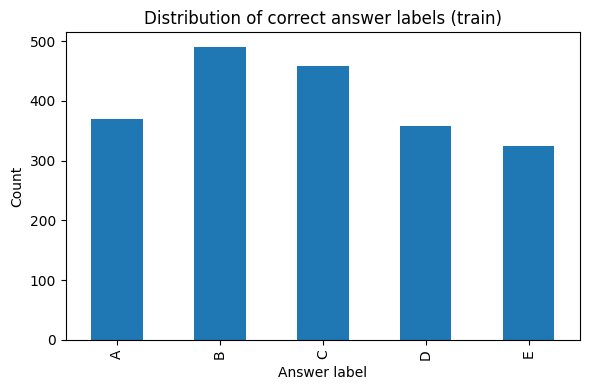


--- Prompt word-length stats (train) ---
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len_words, dtype: float64

--- Prompt word-length stats (test) ---
count    500.000000
mean      15.884000
std        7.446169
min        3.000000
25%       10.000000
50%       15.000000
75%       20.000000
max       52.000000
Name: prompt_len_words, dtype: float64


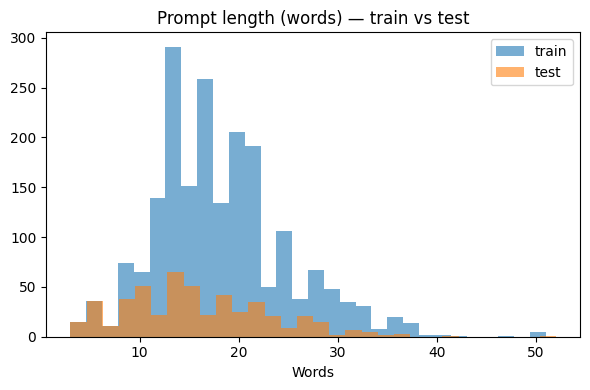


--- Option word-length stats (train) ---
             A_len        B_len       C_len        D_len        E_len
count  2000.000000  2000.000000  2000.00000  2000.000000  2000.000000
mean     26.146000    26.516000    26.54950    25.999500    26.187000
std      17.249651    18.653893    17.20987    17.098909    17.852658
min       1.000000     1.000000     1.00000     1.000000     1.000000
25%      13.000000    12.000000    14.75000    15.000000    13.000000
50%      22.000000    23.000000    24.00000    22.000000    23.000000
75%      37.000000    36.000000    36.00000    36.000000    36.000000
max      81.000000   118.000000    82.00000    78.000000   105.000000


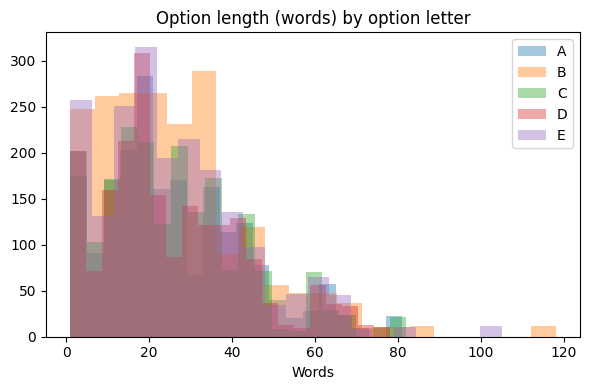


% of time correct answer is the LONGEST option: 34.949999999999996
% of time correct answer is the SHORTEST option: 15.6
(Random baseline would be ~20% for each)

--- 5 random sample questions ---

PROMPT: Select the most accurate option: What is the propagation constant in sinusoidal waves? carefully.
  A: The propagation constant is a measure of the amplitude of the sinusoidal wave that varies with distance.
  B: The propagation constant is a real number that remains constant with distance due to the phase change in the sinusoidal wave.
  C: The propagation constant is a real number that varies with distance due to the phase change in the sinusoidal wave.
  D: The propagation constant is a complex number that varies with distance due to the phase change in the sinusoidal wave. <-- CORRECT
  E: The propagation constant is a complex number that remains constant with distance due to the phase change in the sinusoidal wave.

PROMPT: Pick the best possible answer: What is the most popula

In [2]:
# ============================================================
# EDA for Smart MCQ Solver Challenge
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print("TRAIN shape:", train.shape)
print("TEST shape:", test.shape)
print("SAMPLE SUB shape:", sample_sub.shape)

print("\n--- train.head() ---")
print(train.head())

print("\n--- test.head() ---")
print(test.head())

print("\n--- sample_submission.head() ---")
print(sample_sub.head())

# ------------------------------------------------------------
# 2. Missing values / dtypes
# ------------------------------------------------------------
print("\n--- Missing values (train) ---")
print(train.isnull().sum())

print("\n--- Missing values (test) ---")
print(test.isnull().sum())

print("\n--- dtypes ---")
print(train.dtypes)

# ------------------------------------------------------------
# 3. Duplicate check
# ------------------------------------------------------------
print("\nDuplicate prompts in train:", train["prompt"].duplicated().sum())
print("Duplicate prompts in test:", test["prompt"].duplicated().sum())
print("Prompts overlapping between train & test:",
      train["prompt"].isin(test["prompt"]).sum())

# ------------------------------------------------------------
# 4. Answer label distribution (
# ------------------------------------------------------------
print("\n--- Answer label distribution ---")
answer_counts = train["answer"].value_counts().sort_index()
print(answer_counts)
print("\nAs %:")
print((answer_counts / len(train) * 100).round(2))

plt.figure(figsize=(6, 4))
answer_counts.plot(kind="bar")
plt.title("Distribution of correct answer labels (train)")
plt.xlabel("Answer label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("answer_distribution.png")
plt.show()

# ------------------------------------------------------------
# 5. Prompt length distribution
# ------------------------------------------------------------
train["prompt_len_words"] = train["prompt"].str.split().apply(len)
test["prompt_len_words"] = test["prompt"].str.split().apply(len)

print("\n--- Prompt word-length stats (train) ---")
print(train["prompt_len_words"].describe())

print("\n--- Prompt word-length stats (test) ---")
print(test["prompt_len_words"].describe())

plt.figure(figsize=(6, 4))
plt.hist(train["prompt_len_words"], bins=30, alpha=0.6, label="train")
plt.hist(test["prompt_len_words"], bins=30, alpha=0.6, label="test")
plt.legend()
plt.title("Prompt length (words) — train vs test")
plt.xlabel("Words")
plt.tight_layout()
plt.savefig("prompt_length_dist.png")
plt.show()

# ------------------------------------------------------------
# 6. Option length distribution (per option column)
# ------------------------------------------------------------
option_cols = ["A", "B", "C", "D", "E"]
for col in option_cols:
    train[f"{col}_len"] = train[col].astype(str).str.split().apply(len)

print("\n--- Option word-length stats (train) ---")
print(train[[f"{c}_len" for c in option_cols]].describe())

plt.figure(figsize=(6, 4))
for col in option_cols:
    plt.hist(train[f"{col}_len"], bins=20, alpha=0.4, label=col)
plt.legend()
plt.title("Option length (words) by option letter")
plt.xlabel("Words")
plt.tight_layout()
plt.savefig("option_length_dist.png")
plt.show()

# ------------------------------------------------------------

# ------------------------------------------------------------
def longest_option_letter(row):
    lens = {c: row[f"{c}_len"] for c in option_cols}
    return max(lens, key=lens.get)

def shortest_option_letter(row):
    lens = {c: row[f"{c}_len"] for c in option_cols}
    return min(lens, key=lens.get)

train["longest_opt"] = train.apply(longest_option_letter, axis=1)
train["shortest_opt"] = train.apply(shortest_option_letter, axis=1)

print("\n% of time correct answer is the LONGEST option:",
      (train["answer"] == train["longest_opt"]).mean() * 100)
print("% of time correct answer is the SHORTEST option:",
      (train["answer"] == train["shortest_opt"]).mean() * 100)
print("(Random baseline would be ~20% for each)")

# ------------------------------------------------------------
# 8. Sample a few full questions to eyeball difficulty/style
# ------------------------------------------------------------
print("\n--- 5 random sample questions ---")
for _, row in train.sample(5, random_state=42).iterrows():
    print("\nPROMPT:", row["prompt"])
    for c in option_cols:
        marker = " <-- CORRECT" if c == row["answer"] else ""
        print(f"  {c}: {row[c]}{marker}")

# ------------------------------------------------------------
# 9. Top TF-IDF terms overall (topic sniffing — what domain is this?)
# ------------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=30, stop_words="english")
tfidf.fit(train["prompt"])
print("\n--- Top 30 TF-IDF terms across prompts (topic hint) ---")
print(sorted(tfidf.vocabulary_.keys()))

# ------------------------------------------------------------
# 10. Quick TF-IDF cosine-similarity baseline (Tier 1 sanity check)
#     NOT expected to cross cutoff, just a sanity baseline + submission
# ------------------------------------------------------------
from sklearn.metrics.pairwise import cosine_similarity

def tfidf_baseline_predict(df):
    preds = []
    vec = TfidfVectorizer(stop_words="english")
    for _, row in df.iterrows():
        texts = [row["prompt"]] + [str(row[c]) for c in option_cols]
        tfidf_matrix = vec.fit_transform(texts)
        sims = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
        ranked = [option_cols[i] for i in np.argsort(-sims)]
        preds.append(" ".join(ranked[:3]))
    return preds

# Evaluate this baseline on a held-out slice of TRAIN to estimate MAP@3
from sklearn.model_selection import train_test_split

def map_at_3(true_labels, pred_strings):
    scores = []
    for true, pred in zip(true_labels, pred_strings):
        pred_list = pred.split()
        if true in pred_list:
            rank = pred_list.index(true) + 1
            scores.append(1.0 / rank)
        else:
            scores.append(0.0)
    return np.mean(scores)

_, val = train_test_split(train, test_size=0.2, random_state=42)
val_preds = tfidf_baseline_predict(val)
baseline_map3 = map_at_3(val["answer"].tolist(), val_preds)
print(f"\nTF-IDF cosine-similarity baseline MAP@3 (on held-out train slice): {baseline_map3:.4f}")
print("(Cutoff to beat: 0.73 — this baseline is just a reference point)")

In [3]:
# ============================================================
# Step 2: Lookup-exploit verification + embedding-based fallback
# Run in Kaggle notebook (needs internet ON for sentence-transformers,
# or use a Kaggle-cached model if internet is off for this comp)
# ============================================================

import pandas as pd
import numpy as np

# train = pd.read_csv("/kaggle/input/smart-mcq-solver-challenge/train.csv")
# test = pd.read_csv("/kaggle/input/smart-mcq-solver-challenge/test.csv")

option_cols = ["A", "B", "C", "D", "E"]

# ------------------------------------------------------------
# 1. Verify: for exact-matched prompts, do the OPTIONS also match?
#    This tells us if the lookup exploit is safe to use.
# ------------------------------------------------------------
train_lookup = {}   # prompt -> list of (opts_tuple, answer)  [handle dupes/conflicts]
for _, row in train.iterrows():
    key = row["prompt"]
    opts = tuple(row[c] for c in option_cols)
    train_lookup.setdefault(key, []).append((opts, row["answer"]))

# check for conflicting answers within train itself for the same prompt+options
conflict_prompts = 0
for key, entries in train_lookup.items():
    unique_answers = set(e[1] for e in entries if True)
    unique_opt_sets = set(e[0] for e in entries)
    if len(unique_opt_sets) == 1 and len(unique_answers) > 1:
        conflict_prompts += 1
print("Train prompts with same options but conflicting answers:", conflict_prompts)

matched = 0
option_exact_match = 0
option_setmatch_diff_order = 0
no_option_match = 0

test_lookup_answer = {}  # test id -> predicted answer via lookup (if confident)

for _, row in test.iterrows():
    key = row["prompt"]
    if key not in train_lookup:
        continue
    matched += 1
    test_opts = tuple(row[c] for c in option_cols)
    entries = train_lookup[key]

    # does any train entry have EXACTLY the same options in the same order?
    exact_hit = [e for e in entries if e[0] == test_opts]
    if exact_hit:
        option_exact_match += 1
        test_lookup_answer[row["id"]] = exact_hit[0][1]
    else:
        # same options but different order? try to realign by content
        test_opt_set = set(test_opts)
        set_hit = [e for e in entries if set(e[0]) == test_opt_set]
        if set_hit:
            option_setmatch_diff_order += 1
            train_opts, train_answer = set_hit[0]
            # find which letter in train had the answer text, map to test's letter for that text
            answer_text = train_opts[option_cols.index(train_answer)]
            test_letter = option_cols[test_opts.index(answer_text)]
            test_lookup_answer[row["id"]] = test_letter
        else:
            no_option_match += 1

print(f"\nTest prompts found in train: {matched}/{len(test)}")
print(f"  -> exact option match (safe, direct copy):        {option_exact_match}")
print(f"  -> same options, different order (realigned):      {option_setmatch_diff_order}")
print(f"  -> prompt matched but options totally different:   {no_option_match}")
print(f"\nTotal test rows we can answer via lookup: {len(test_lookup_answer)}")

# ------------------------------------------------------------
# 2. Embedding-based fallback for everything NOT in the lookup
#    Strategy: embed (prompt + each option) for train & test,
#    find nearest train question by prompt-embedding similarity,
#    then rank test options by similarity to the matched context
#    PLUS blend in the "longest option" prior as a tiebreaker signal.
# ------------------------------------------------------------
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")  # fast, good enough for retrieval

train_prompt_emb = model.encode(train["prompt"].tolist(), show_progress_bar=True, batch_size=64)

def fallback_predict_row(row, train_prompt_emb, train_df, top_k_context=3):
    """
    1. Find nearest train prompt(s) by embedding similarity (paraphrase/near-dup retrieval).
    2. Also embed this row's own options against the prompt to rank by relevance.
    3. Blend nearest-neighbor answer signal with direct option-relevance signal.
    """
    q_emb = model.encode([row["prompt"]])
    sims_to_train = cosine_similarity(q_emb, train_prompt_emb).flatten()
    top_idx = np.argsort(-sims_to_train)[:top_k_context]

    # signal A: does the *content* of any option match a near-neighbor's correct answer content?
    nn_scores = {c: 0.0 for c in option_cols}
    for idx in top_idx:
        nn_row = train_df.iloc[idx]
        nn_answer_text = nn_row[nn_row["answer"]]
        nn_answer_emb = model.encode([nn_answer_text])
        row_opt_embs = model.encode([str(row[c]) for c in option_cols])
        opt_sims = cosine_similarity(nn_answer_emb, row_opt_embs).flatten()
        weight = sims_to_train[idx]
        for i, c in enumerate(option_cols):
            nn_scores[c] += opt_sims[i] * weight

    # signal B: raw prompt-vs-option relevance (like the TF-IDF baseline but semantic)
    prompt_emb = model.encode([row["prompt"]])
    opt_embs = model.encode([str(row[c]) for c in option_cols])
    direct_sims = cosine_similarity(prompt_emb, opt_embs).flatten()

    # combine (weight nearest-neighbor signal higher — it's the stronger one here)
    combined = {}
    for i, c in enumerate(option_cols):
        combined[c] = 0.7 * nn_scores[c] + 0.3 * direct_sims[i]

    ranked = sorted(combined, key=combined.get, reverse=True)
    return ranked[:3]

# NOTE: the per-row re-encoding above is slow for 500 rows (re-embeds train options each time).
# This is a clear, readable first pass. Once it's working, ping me and I'll help you
# vectorize it (pre-encode all train option texts once, reuse embeddings) so it runs fast.

# ------------------------------------------------------------
# 3. Build final submission: lookup where available, fallback otherwise
# ------------------------------------------------------------
predictions = []
needs_fallback = test[~test["id"].isin(test_lookup_answer.keys())].reset_index(drop=True)
print(f"\nRows needing fallback model: {len(needs_fallback)}")

for _, row in test.iterrows():
    if row["id"] in test_lookup_answer:
        answer = test_lookup_answer[row["id"]]
        others = [c for c in option_cols if c != answer]
        # put looked-up answer first, then two others as filler
        # (use the length-bias prior to order the filler: longer options slightly more likely)
        others_sorted = sorted(others, key=lambda c: len(str(row[c])), reverse=True)
        pred = [answer] + others_sorted[:2]
    else:
        pred = fallback_predict_row(row, train_prompt_emb, train)
    predictions.append(" ".join(pred))

submission = pd.DataFrame({"ID": test["id"], "Prediction": predictions})
submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv")
print(submission.head(10))

Train prompts with same options but conflicting answers: 0

Test prompts found in train: 268/500
  -> exact option match (safe, direct copy):        257
  -> same options, different order (realigned):      0
  -> prompt matched but options totally different:   11

Total test rows we can answer via lookup: 257


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Rows needing fallback model: 243

Saved submission.csv
   ID Prediction
0   1      A D C
1   2      B E D
2   3      B D E
3   4      E C A
4   5      C E A
5   6      D A E
6   7      E D A
7   8      B D A
8   9      C E D
9  10      B E A


In [ ]:
# ============================================================
# Model 3: From-scratch model — BiLSTM encoder, randomly initialized
# embeddings (NOT pretrained GloVe/word2vec — this must be "from scratch"
# per the milestone requirement). Trains fast on CPU or GPU.
# ============================================================

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
import wandb

option_cols = ["A", "B", "C", "D", "E"]
label_to_idx = {c: i for i, c in enumerate(option_cols)}

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# ------------------------------------------------------------
# 1. Same grouped split as Model 2 (no paraphrase leakage)
# ------------------------------------------------------------
def group_key(row):
    return frozenset(str(row[c]) for c in option_cols)

train["group"] = train.apply(group_key, axis=1)
gkf = GroupKFold(n_splits=5)
train_idx, val_idx = next(gkf.split(train, groups=train["group"]))
tr_df = train.iloc[train_idx].reset_index(drop=True)
val_df = train.iloc[val_idx].reset_index(drop=True)
print(f"Train: {len(tr_df)} | Val: {len(val_df)}")

# ------------------------------------------------------------
# 2. Build vocabulary from scratch (word-level, whitespace + regex tokenizer)
# ------------------------------------------------------------
def tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

all_text = []
for _, row in tr_df.iterrows():
    all_text.append(row["prompt"])
    for c in option_cols:
        all_text.append(row[c])

word_freq = {}
for text in all_text:
    for tok in tokenize(text):
        word_freq[tok] = word_freq.get(tok, 0) + 1

# keep words appearing at least twice, cap vocab size
MIN_FREQ = 2
MAX_VOCAB = 20000
vocab_words = [w for w, f in word_freq.items() if f >= MIN_FREQ]
vocab_words = sorted(vocab_words, key=lambda w: -word_freq[w])[:MAX_VOCAB]

word2idx = {"<pad>": 0, "<unk>": 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print("Vocab size:", VOCAB_SIZE)

MAX_LEN = 40

def encode(text):
    toks = tokenize(text)[:MAX_LEN]
    ids = [word2idx.get(t, 1) for t in toks]
    ids = ids + [0] * (MAX_LEN - len(ids))
    return ids

# ------------------------------------------------------------
# 3. Dataset: each example = prompt tokens + 5 option token sequences
# ------------------------------------------------------------
class MCQDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_ids = torch.tensor(encode(row["prompt"]), dtype=torch.long)
        option_ids = torch.stack([
            torch.tensor(encode(row[c]), dtype=torch.long) for c in option_cols
        ])  # shape (5, MAX_LEN)
        if self.has_labels:
            label = label_to_idx[row["answer"]]
            return prompt_ids, option_ids, label
        return prompt_ids, option_ids

train_dataset = MCQDataset(tr_df)
val_dataset = MCQDataset(val_df)
test_dataset = MCQDataset(test, has_labels=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# ------------------------------------------------------------
# 4. Model: shared BiLSTM encoder for prompt & options, score via
#    dot-product similarity (randomly initialized embeddings — from scratch)
# ------------------------------------------------------------
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)
        out, (h_n, _) = self.lstm(emb)
        # concat final forward + backward hidden states
        final = torch.cat([h_n[0], h_n[1]], dim=1)  # (batch, hidden_dim*2)
        return final

class MCQFromScratchModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.encoder = BiLSTMEncoder(vocab_size, emb_dim, hidden_dim)
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, prompt_ids, option_ids):
        # prompt_ids: (batch, seq_len)
        # option_ids: (batch, 5, seq_len)
        batch_size, num_choices, seq_len = option_ids.shape

        prompt_vec = self.encoder(prompt_ids)  # (batch, hidden*2)
        prompt_vec = prompt_vec.unsqueeze(1).expand(-1, num_choices, -1)  # (batch, 5, hidden*2)

        options_flat = option_ids.view(batch_size * num_choices, seq_len)
        option_vec = self.encoder(options_flat)  # (batch*5, hidden*2)
        option_vec = option_vec.view(batch_size, num_choices, -1)  # (batch, 5, hidden*2)

        combined = torch.cat([prompt_vec, option_vec], dim=2)  # (batch, 5, hidden*4)
        scores = self.scorer(combined).squeeze(-1)  # (batch, 5)
        return scores

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MCQFromScratchModel(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 5. MAP@3 metric
# ------------------------------------------------------------
def map3_score(logits, labels):
    top3 = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for row_top3, true in zip(top3, labels):
        if true in row_top3:
            scores.append(1.0 / (list(row_top3).index(true) + 1))
        else:
            scores.append(0.0)
    return np.mean(scores)

# ------------------------------------------------------------
# 6. Train loop with W&B logging
# ------------------------------------------------------------
wandb.init(project="23f1001159-t22026", name="model3_bilstm_from_scratch")

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for prompt_ids, option_ids, labels in train_loader:
        prompt_ids, option_ids, labels = prompt_ids.to(device), option_ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(prompt_ids, option_ids)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # validation
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for prompt_ids, option_ids, labels in val_loader:
            prompt_ids, option_ids = prompt_ids.to(device), option_ids.to(device)
            logits = model(prompt_ids, option_ids)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    all_logits = np.concatenate(all_logits)
    all_labels = np.concatenate(all_labels)
    val_acc = (np.argmax(all_logits, axis=1) == all_labels).mean()
    val_map3 = map3_score(all_logits, all_labels)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={avg_train_loss:.4f} | val_acc={val_acc:.4f} | val_map3={val_map3:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_accuracy": val_acc,
        "val_map3": val_map3,
    })

# ------------------------------------------------------------
# 7. Inference on test set
# ------------------------------------------------------------
model.eval()
all_test_logits = []
with torch.no_grad():
    for prompt_ids, option_ids in test_loader:
        prompt_ids, option_ids = prompt_ids.to(device), option_ids.to(device)
        logits = model(prompt_ids, option_ids)
        all_test_logits.append(logits.cpu().numpy())
all_test_logits = np.concatenate(all_test_logits)

top3_idx = np.argsort(-all_test_logits, axis=1)[:, :3]
top3_letters = [[option_cols[i] for i in row] for row in top3_idx]

submission = pd.DataFrame({
    "ID": test["id"],
    "Prediction": [" ".join(letters) for letters in top3_letters],
})
submission.to_csv("submission_bilstm_scratch.csv", index=False)
print(submission.head())

torch.save(model.state_dict(), "bilstm_scratch_model.pt")
wandb.finish()

Train: 1600 | Val: 400
Vocab size: 2978


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f1001159 (23f1001159-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/15 | train_loss=1.1838 | val_acc=0.8975 | val_map3=0.9346
Epoch 2/15 | train_loss=0.1827 | val_acc=0.9475 | val_map3=0.9692
Epoch 3/15 | train_loss=0.0982 | val_acc=0.9750 | val_map3=0.9838
Epoch 4/15 | train_loss=0.0454 | val_acc=0.9775 | val_map3=0.9850
Epoch 5/15 | train_loss=0.0362 | val_acc=0.9775 | val_map3=0.9850


In [ ]:
# ============================================================
# Model 2: Pretrained fine-tune — DeBERTa-v3-base for Multiple Choice
# Run on Kaggle with GPU (T4/P100) turned ON.
# ============================================================

import pandas as pd
import numpy as np
import torch
import wandb
from sklearn.model_selection import GroupKFold
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
)
from dataclasses import dataclass
from typing import Optional, Union
import torch.nn.functional as F

option_cols = ["A", "B", "C", "D", "E"]
label_to_idx = {c: i for i, c in enumerate(option_cols)}

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# ------------------------------------------------------------
# 1. Group key to prevent paraphrase leakage across train/val split
#    (group by the SET of option texts — paraphrased prompts share
#    the same underlying options)
# ------------------------------------------------------------
def group_key(row):
    return frozenset(str(row[c]) for c in option_cols)

train["group"] = train.apply(group_key, axis=1)
print("Unique question groups:", train["group"].nunique(), "out of", len(train), "rows")

gkf = GroupKFold(n_splits=5)
train_idx, val_idx = next(gkf.split(train, groups=train["group"]))
tr_df = train.iloc[train_idx].reset_index(drop=True)
val_df = train.iloc[val_idx].reset_index(drop=True)
print(f"Train: {len(tr_df)} rows | Val: {len(val_df)} rows (grouped split, no leakage)")

# ------------------------------------------------------------
# 2. Tokenization for multiple-choice: each (prompt, option) pair
#    gets tokenized as one of 5 "choices" for that example.
# ------------------------------------------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Kaggle Settings -> Accelerator -> GPU, "
          "then restart the session and re-run from the top before continuing.")

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(df):
    first_sentences = [[str(p)] * 5 for p in df["prompt"]]
    second_sentences = [[str(df.iloc[i][c]) for c in option_cols] for i in range(len(df))]
    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    tokenized = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        max_length=256,
        padding="max_length",
    )
    # reshape flat lists back into (num_examples, 5, seq_len)
    out = {k: [v[i:i+5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}
    if "answer" in df.columns:
        out["labels"] = [label_to_idx[a] for a in df["answer"]]
    return out

from datasets import Dataset

tr_dataset = Dataset.from_dict(preprocess(tr_df))
val_dataset = Dataset.from_dict(preprocess(val_df))
test_dataset = Dataset.from_dict(preprocess(test))

# ------------------------------------------------------------
# 3. Data collator for multiple choice (handles the extra "choices" dim)
# ------------------------------------------------------------
@dataclass
class DataCollatorForMultipleChoice:
    tokenizer: any
    padding: Union[bool, str] = True
    max_length: Optional[int] = None

    def __call__(self, features):
        label_name = "labels" if "labels" in features[0].keys() else None
        labels = [f.pop(label_name) for f in features] if label_name else None
        batch_size = len(features)
        num_choices = len(features[0]["input_ids"])
        flattened = [
            [{k: v[i] for k, v in f.items()} for i in range(num_choices)]
            for f in features
        ]
        flattened = sum(flattened, [])
        batch = self.tokenizer.pad(
            flattened,
            padding=self.padding,
            max_length=self.max_length,
            return_tensors="pt",
        )
        batch = {k: v.view(batch_size, num_choices, -1) for k, v in batch.items()}
        if labels is not None:
            batch["labels"] = torch.tensor(labels, dtype=torch.int64)
        return batch

collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

# ------------------------------------------------------------
# 4. MAP@3 metric
# ------------------------------------------------------------
def map3_from_logits(logits, labels):
    top3 = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for row_top3, true in zip(top3, labels):
        if true in row_top3:
            rank = list(row_top3).index(true) + 1
            scores.append(1.0 / rank)
        else:
            scores.append(0.0)
    return np.mean(scores)

from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = (preds == labels).mean()
    f1 = f1_score(labels, preds, average="macro")
    map3 = map3_from_logits(logits, labels)
    return {"accuracy": acc, "f1": f1, "map3": map3}

# ------------------------------------------------------------
# ------------------------------------------------------------
wandb.init(project="23f1001159-t22026", name="model2_deberta_v3_finetune")

# ------------------------------------------------------------
# 6. Train
# ------------------------------------------------------------
model = AutoModelForMultipleChoice.from_pretrained(MODEL_NAME)

args = TrainingArguments(
    output_dir="./deberta_mc_output",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=6,
    weight_decay=0.01,
    report_to="wandb",
    load_best_model_at_end=True,
    metric_for_best_model="map3",
    greater_is_better=True,
    fp16=False,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    logging_steps=10,
    max_grad_norm=1.0,
)

# Sanity check: confirm the classifier head actually has trainable gradients
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")
for name, p in model.named_parameters():
    if "classifier" in name or "pooler" in name:
        print(f"  {name}: requires_grad={p.requires_grad}, shape={tuple(p.shape)}")

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tr_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

import os
import shutil

# Clear any stale checkpoint dir from a previous broken run so we always
# start this run from true pretrained weights, not a bad resume point.
if os.path.isdir("./deberta_mc_output"):
    shutil.rmtree("./deberta_mc_output")
    print("Cleared stale ./deberta_mc_output before starting fresh run.")

last_checkpoint = None
trainer.train(resume_from_checkpoint=last_checkpoint)

val_results = trainer.evaluate()
print("Validation results:", val_results)
wandb.log({"final_val_map3": val_results["eval_map3"], "final_val_accuracy": val_results["eval_accuracy"]})

# ------------------------------------------------------------
# 7. Inference on test set -> top-3 predictions
# ------------------------------------------------------------
preds = trainer.predict(test_dataset)
logits = preds.predictions
top3_idx = np.argsort(-logits, axis=1)[:, :3]
top3_letters = [[option_cols[i] for i in row] for row in top3_idx]

submission = pd.DataFrame({
    "ID": test["id"],
    "Prediction": [" ".join(letters) for letters in top3_letters],
})
submission.to_csv("submission_deberta.csv", index=False)
print(submission.head())

# save model for reuse / deployment
trainer.save_model("./deberta_mc_final")
tokenizer.save_pretrained("./deberta_mc_final")

wandb.finish()

#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

In [ ]:
train.head()

In [ ]:
# ============================================================
# Model 1: Lookup + Embedding Retrieval — proper W&B validation run
# Evaluates on the SAME grouped train/val split as Models 2 & 3,
# so all three models are directly comparable on accuracy, F1, MAP@3.
# ============================================================

import pandas as pd
import numpy as np
import wandb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

option_cols = ["A", "B", "C", "D", "E"]
label_to_idx = {c: i for i, c in enumerate(option_cols)}

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# ------------------------------------------------------------
# 1. SAME grouped split as Models 2 & 3 (group by option-content set)
# ------------------------------------------------------------
def group_key(row):
    return frozenset(str(row[c]) for c in option_cols)

train["group"] = train.apply(group_key, axis=1)
gkf = GroupKFold(n_splits=5)
train_idx, val_idx = next(gkf.split(train, groups=train["group"]))
tr_df = train.iloc[train_idx].reset_index(drop=True)
val_df = train.iloc[val_idx].reset_index(drop=True)
print(f"Train (reference pool): {len(tr_df)} | Val (queries): {len(val_df)}")

# ------------------------------------------------------------
# 2. Build the lookup table from the TRAIN split only
#    (val questions are, by construction of GroupKFold, held out —
#    so any exact-match lookup hits here reflect genuine near-duplicate
#    structure in the data, not leakage from the answer itself)
# ------------------------------------------------------------
train_lookup = {}
for _, row in tr_df.iterrows():
    key = row["prompt"]
    opts = tuple(row[c] for c in option_cols)
    train_lookup.setdefault(key, []).append((opts, row["answer"]))

# ------------------------------------------------------------
# 3. Embedding model + pre-encode the train pool once (fast)
# ------------------------------------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")
train_prompt_emb = model.encode(tr_df["prompt"].tolist(), show_progress_bar=True, batch_size=64)

# pre-encode train answer texts (the text of the correct option for each train row)
train_answer_texts = [row[row["answer"]] for _, row in tr_df.iterrows()]
train_answer_emb = model.encode(train_answer_texts, show_progress_bar=True, batch_size=64)

def predict_row(row, top_k=3):
    key = row["prompt"]
    test_opts = tuple(row[c] for c in option_cols)

    # exact lookup first
    if key in train_lookup:
        exact_hit = [e for e in train_lookup[key] if e[0] == test_opts]
        if exact_hit:
            answer = exact_hit[0][1]
            others = [c for c in option_cols if c != answer]
            others_sorted = sorted(others, key=lambda c: len(str(row[c])), reverse=True)
            return [answer] + others_sorted[:top_k - 1]

    # fallback: nearest-neighbor retrieval + option relevance
    q_emb = model.encode([row["prompt"]])
    sims_to_train = cosine_similarity(q_emb, train_prompt_emb).flatten()
    top_idx = np.argsort(-sims_to_train)[:3]

    row_opt_embs = model.encode([str(row[c]) for c in option_cols])
    nn_scores = {c: 0.0 for c in option_cols}
    for idx in top_idx:
        weight = sims_to_train[idx]
        opt_sims = cosine_similarity(train_answer_emb[idx:idx+1], row_opt_embs).flatten()
        for i, c in enumerate(option_cols):
            nn_scores[c] += opt_sims[i] * weight

    prompt_emb = model.encode([row["prompt"]])
    direct_sims = cosine_similarity(prompt_emb, row_opt_embs).flatten()

    combined = {c: 0.7 * nn_scores[c] + 0.3 * direct_sims[i] for i, c in enumerate(option_cols)}
    ranked = sorted(combined, key=combined.get, reverse=True)
    return ranked[:top_k]

# ------------------------------------------------------------
# 4. Run predictions on validation split
# ------------------------------------------------------------
all_top3 = []
all_labels = []
for _, row in val_df.iterrows():
    top3 = predict_row(row)
    all_top3.append(top3)
    all_labels.append(row["answer"])

# ------------------------------------------------------------
# 5. Metrics: accuracy (top-1 = first prediction), macro F1, MAP@3
# ------------------------------------------------------------
top1_preds = [t[0] for t in all_top3]
val_acc = np.mean([p == t for p, t in zip(top1_preds, all_labels)])
val_f1 = f1_score(
    [label_to_idx[l] for l in all_labels],
    [label_to_idx[p] for p in top1_preds],
    average="macro",
)

def map3(top3_list, labels):
    scores = []
    for top3, true in zip(top3_list, labels):
        if true in top3:
            scores.append(1.0 / (top3.index(true) + 1))
        else:
            scores.append(0.0)
    return np.mean(scores)

val_map3 = map3(all_top3, all_labels)

print(f"\nModel 1 (Lookup + Retrieval) on grouped validation split:")
print(f"  Accuracy: {val_acc:.4f}")
print(f"  Macro F1: {val_f1:.4f}")
print(f"  MAP@3:    {val_map3:.4f}")

# ------------------------------------------------------------
# 6. Log to W&B — same project as Models 2 & 3
# ------------------------------------------------------------
wandb.init(project="23f1001159-t22026", name="model1_lookup_retrieval")
wandb.log({
    "val_accuracy": val_acc,
    "val_f1": val_f1,
    "val_map3": val_map3,
    "kaggle_leaderboard_map3": 0.7510,  # from actual submission
})
wandb.finish()

In [ ]:
# ============================================================
# Model 3: From-scratch model — BiLSTM encoder, randomly initialized
# embeddings (NOT pretrained GloVe/word2vec — this must be "from scratch"
# per the milestone requirement). Trains fast on CPU or GPU.
# ============================================================

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
import wandb

option_cols = ["A", "B", "C", "D", "E"]
label_to_idx = {c: i for i, c in enumerate(option_cols)}

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# ------------------------------------------------------------
# 1. Same grouped split as Model 2 (no paraphrase leakage)
# ------------------------------------------------------------
def group_key(row):
    return frozenset(str(row[c]) for c in option_cols)

train["group"] = train.apply(group_key, axis=1)
gkf = GroupKFold(n_splits=5)
train_idx, val_idx = next(gkf.split(train, groups=train["group"]))
tr_df = train.iloc[train_idx].reset_index(drop=True)
val_df = train.iloc[val_idx].reset_index(drop=True)
print(f"Train: {len(tr_df)} | Val: {len(val_df)}")

# ------------------------------------------------------------
# 2. Build vocabulary from scratch (word-level, whitespace + regex tokenizer)
# ------------------------------------------------------------
def tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

all_text = []
for _, row in tr_df.iterrows():
    all_text.append(row["prompt"])
    for c in option_cols:
        all_text.append(row[c])

word_freq = {}
for text in all_text:
    for tok in tokenize(text):
        word_freq[tok] = word_freq.get(tok, 0) + 1

# keep words appearing at least twice, cap vocab size
MIN_FREQ = 2
MAX_VOCAB = 20000
vocab_words = [w for w, f in word_freq.items() if f >= MIN_FREQ]
vocab_words = sorted(vocab_words, key=lambda w: -word_freq[w])[:MAX_VOCAB]

word2idx = {"<pad>": 0, "<unk>": 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print("Vocab size:", VOCAB_SIZE)

MAX_LEN = 40

def encode(text):
    toks = tokenize(text)[:MAX_LEN]
    ids = [word2idx.get(t, 1) for t in toks]
    ids = ids + [0] * (MAX_LEN - len(ids))
    return ids

# ------------------------------------------------------------
# 3. Dataset: each example = prompt tokens + 5 option token sequences
# ------------------------------------------------------------
class MCQDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_ids = torch.tensor(encode(row["prompt"]), dtype=torch.long)
        option_ids = torch.stack([
            torch.tensor(encode(row[c]), dtype=torch.long) for c in option_cols
        ])  # shape (5, MAX_LEN)
        if self.has_labels:
            label = label_to_idx[row["answer"]]
            return prompt_ids, option_ids, label
        return prompt_ids, option_ids

train_dataset = MCQDataset(tr_df)
val_dataset = MCQDataset(val_df)
test_dataset = MCQDataset(test, has_labels=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# ------------------------------------------------------------
# 4. Model: shared BiLSTM encoder for prompt & options, score via
#    dot-product similarity (randomly initialized embeddings — from scratch)
# ------------------------------------------------------------
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)
        out, (h_n, _) = self.lstm(emb)
        # concat final forward + backward hidden states
        final = torch.cat([h_n[0], h_n[1]], dim=1)  # (batch, hidden_dim*2)
        return final

class MCQFromScratchModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.encoder = BiLSTMEncoder(vocab_size, emb_dim, hidden_dim)
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, prompt_ids, option_ids):
        # prompt_ids: (batch, seq_len)
        # option_ids: (batch, 5, seq_len)
        batch_size, num_choices, seq_len = option_ids.shape

        prompt_vec = self.encoder(prompt_ids)  # (batch, hidden*2)
        prompt_vec = prompt_vec.unsqueeze(1).expand(-1, num_choices, -1)  # (batch, 5, hidden*2)

        options_flat = option_ids.view(batch_size * num_choices, seq_len)
        option_vec = self.encoder(options_flat)  # (batch*5, hidden*2)
        option_vec = option_vec.view(batch_size, num_choices, -1)  # (batch, 5, hidden*2)

        combined = torch.cat([prompt_vec, option_vec], dim=2)  # (batch, 5, hidden*4)
        scores = self.scorer(combined).squeeze(-1)  # (batch, 5)
        return scores

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MCQFromScratchModel(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 5. MAP@3 metric
# ------------------------------------------------------------
from sklearn.metrics import f1_score

def map3_score(logits, labels):
    top3 = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for row_top3, true in zip(top3, labels):
        if true in row_top3:
            scores.append(1.0 / (list(row_top3).index(true) + 1))
        else:
            scores.append(0.0)
    return np.mean(scores)

# ------------------------------------------------------------
# 6. Train loop with W&B logging
# ------------------------------------------------------------
wandb.init(project="23f1001159-t22026", name="model3_bilstm_from_scratch")

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for prompt_ids, option_ids, labels in train_loader:
        prompt_ids, option_ids, labels = prompt_ids.to(device), option_ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(prompt_ids, option_ids)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # validation
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for prompt_ids, option_ids, labels in val_loader:
            prompt_ids, option_ids = prompt_ids.to(device), option_ids.to(device)
            logits = model(prompt_ids, option_ids)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    all_logits = np.concatenate(all_logits)
    all_labels = np.concatenate(all_labels)
    val_acc = (np.argmax(all_logits, axis=1) == all_labels).mean()
    val_f1 = f1_score(all_labels, np.argmax(all_logits, axis=1), average="macro")
    val_map3 = map3_score(all_logits, all_labels)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={avg_train_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_map3={val_map3:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "val_map3": val_map3,
    })

# ------------------------------------------------------------
# 7. Inference on test set
# ------------------------------------------------------------
model.eval()
all_test_logits = []
with torch.no_grad():
    for prompt_ids, option_ids in test_loader:
        prompt_ids, option_ids = prompt_ids.to(device), option_ids.to(device)
        logits = model(prompt_ids, option_ids)
        all_test_logits.append(logits.cpu().numpy())
all_test_logits = np.concatenate(all_test_logits)

top3_idx = np.argsort(-all_test_logits, axis=1)[:, :3]
top3_letters = [[option_cols[i] for i in row] for row in top3_idx]

submission = pd.DataFrame({
    "ID": test["id"],
    "Prediction": [" ".join(letters) for letters in top3_letters],
})
submission.to_csv("submission_bilstm_scratch.csv", index=False)
print(submission.head())

torch.save(model.state_dict(), "bilstm_scratch_model.pt")
wandb.finish()